*[https://www.kaggle.com/datasets/shivamb/netflix-shows]*

**About this Dataset:**

Netflix is one of the most popular media and video streaming platforms. They have over 8000 movies or tv shows available on their platform, as of mid-2021, they have over 200M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.

This report presents a comprehensive exploratory data analysis (EDA) of the Netflix content library dataset. The analysis covers content type distribution, release trends, geographic origins, genre patterns, ratings, duration statistics, cast and director profiles, and seasonal patterns for TV shows. Each chart is interpreted individually, followed by an overarching summary of key findings.

In [2]:
# Import Libraries which are requried.
import numpy as np
import pandas as pd

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [4]:
import os

# List the contents of the downloaded Kaggle dataset directory
print(os.listdir(path))

['netflix_titles.csv']


In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Define the path to save the CSV in Google Drive
gdrive_path = '/content/drive/MyDrive/netflix_titles_output.csv'

print(f"Dataset saved to: {gdrive_path}")

Mounted at /content/drive
Dataset saved to: /content/drive/MyDrive/netflix_titles_output.csv


In [6]:
dataset='/content/drive/MyDrive/netflix_titles_output.csv'
netflix_df=pd.read_csv(dataset)
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
netflix_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
netflix_df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


The analysis of the release_year feature reveals that the dataset is heavily skewed towards modern content.

The median release year is 2017, indicating that more than 50% of the titles were released after this year.
The interquartile range (2013–2019) shows that the majority of the content is concentrated within recent years.
Although the dataset includes very old titles (as early as 1925), these are limited and act as outliers rather than representing the overall distribution.
The standard deviation (~9 years) suggests a moderate spread, but still centered around recent productions.


This distribution indicates that Netflix primarily focuses on recent and modern content, aligning with user demand for up-to-date media.

In [9]:
# Columns in the dataset
netflix_df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [10]:
# Shape of The data frame
netflix_df.shape # 12 Columns and 8807 Rows

(8807, 12)

In [11]:
# How many years of Data (1966-2021)
netflix_df["release_year"].value_counts()

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
...,...
1961,1
1925,1
1959,1


In [12]:
# MOVIES vs TV SHOWS
netflix_df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [13]:
netflix_df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
# Replace NAN value(s) with TV-MA
netflix_df['rating'].replace(np.nan, 'TV-MA',inplace  = True)

/tmp/ipykernel_2608/2987127767.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix_df['rating'].replace(np.nan, 'TV-MA',inplace  = True)


In [15]:
netflix_df["rating"].isnull().sum()

np.int64(0)

In [16]:
# Replace NAN value(s) with United States
netflix_df['country'].replace(np.nan, 'United States',inplace = True)

/tmp/ipykernel_2608/1082078518.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix_df['country'].replace(np.nan, 'United States',inplace = True)


In [17]:
# Rename the Column "listed_in" to "genre"
netflix_df.rename(columns={'listed_in': 'genre'},
          inplace=True, errors='raise')

In [18]:
netflix_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [19]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

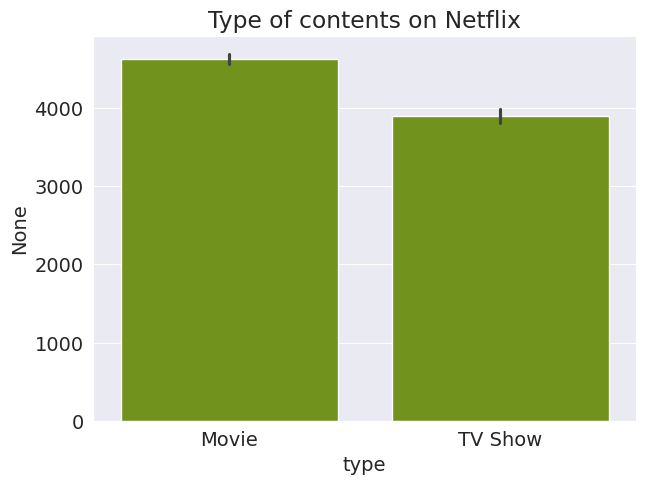

In [20]:
# TV SHOW VS MOVIES On NETFLIX - BAR CHART
plt.figure(figsize=(7,5))
plt.title('Type of contents on Netflix')
sns.barplot(x=netflix_df['type'], y=netflix_df.index, color="#7aa609")
plt.show()

The bar chart compares the raw count of Movies versus TV Shows on Netflix. Movies dominate the platform with approximately 4,500 titles, while TV Shows account for roughly 3,900 titles. Although both categories are substantial, movies hold a clear lead.

Text(0.5, 1.0, 'Distribution ratio of content types')

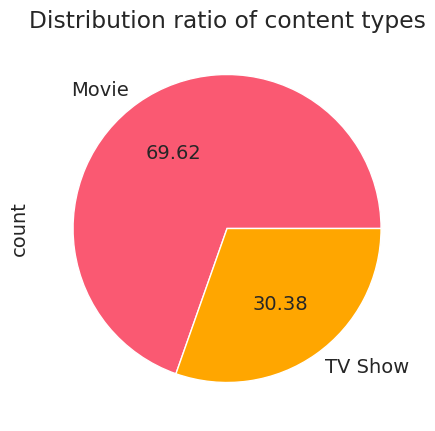

In [21]:
netflix_df["type"].value_counts().plot(kind="pie", figsize=(7,5), autopct="%.2f", colors=["#fa5972","#ffa600"] )
plt.title("Distribution ratio of content types")

The pie chart quantifies this split precisely: Movies account for 69.62% of all Netflix content, while TV Shows make up the remaining 30.38%. This near 70/30 split reveals that Netflix has historically leaned heavily on film licensing and acquisition, while its TV Show library — though growing — remains a secondary focus in terms of sheer volume.

Text(0.5, 1.0, 'The most popular genres')

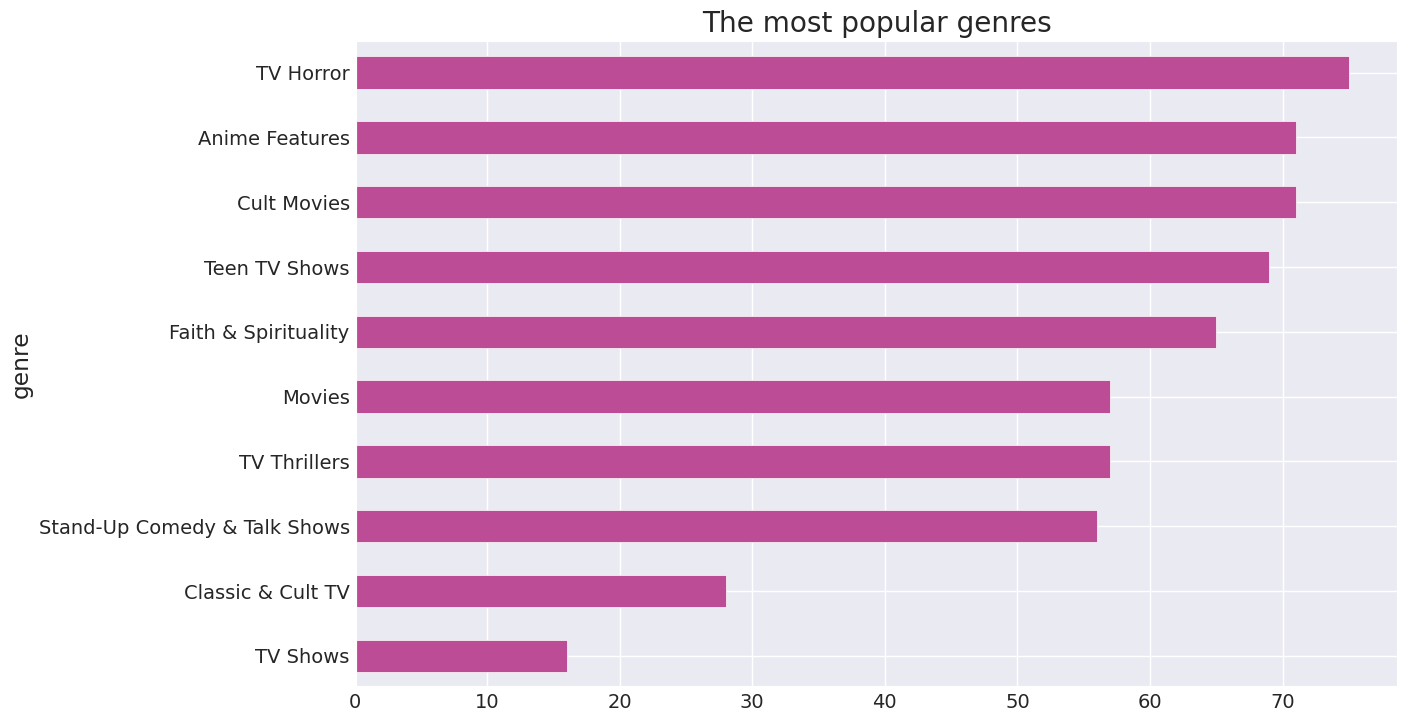

In [78]:
plt.figure(figsize = (12,8))
netflix_df['genre'].str.split(', ').explode().value_counts().sort_values(ascending=True).head(10).plot(kind='barh', color="#bc4c96")
plt.title("The most popular genres")


This chart splits multi-genre tags into individual genres and counts each independently. TV Horror ranks first (76 titles), followed closely by Anime Features (72), Cult Movies (72), Teen TV Shows (70), and Faith & Spirituality (65). Classic content categories like 'Movies' and 'TV Shows' appear at the bottom as generic fallback labels with ~55 and ~16 titles respectively.
Observations:
•	Niche genres like TV Horror and Cult Movies have more individual titles than mainstream labels — this reflects genre-specific cataloging.
•	Anime Features' high ranking confirms anime's growing global audience and Netflix's investment in this segment.
•	Teen TV Shows and Faith & Spirituality suggest Netflix is intentionally serving underserved demographic niches.


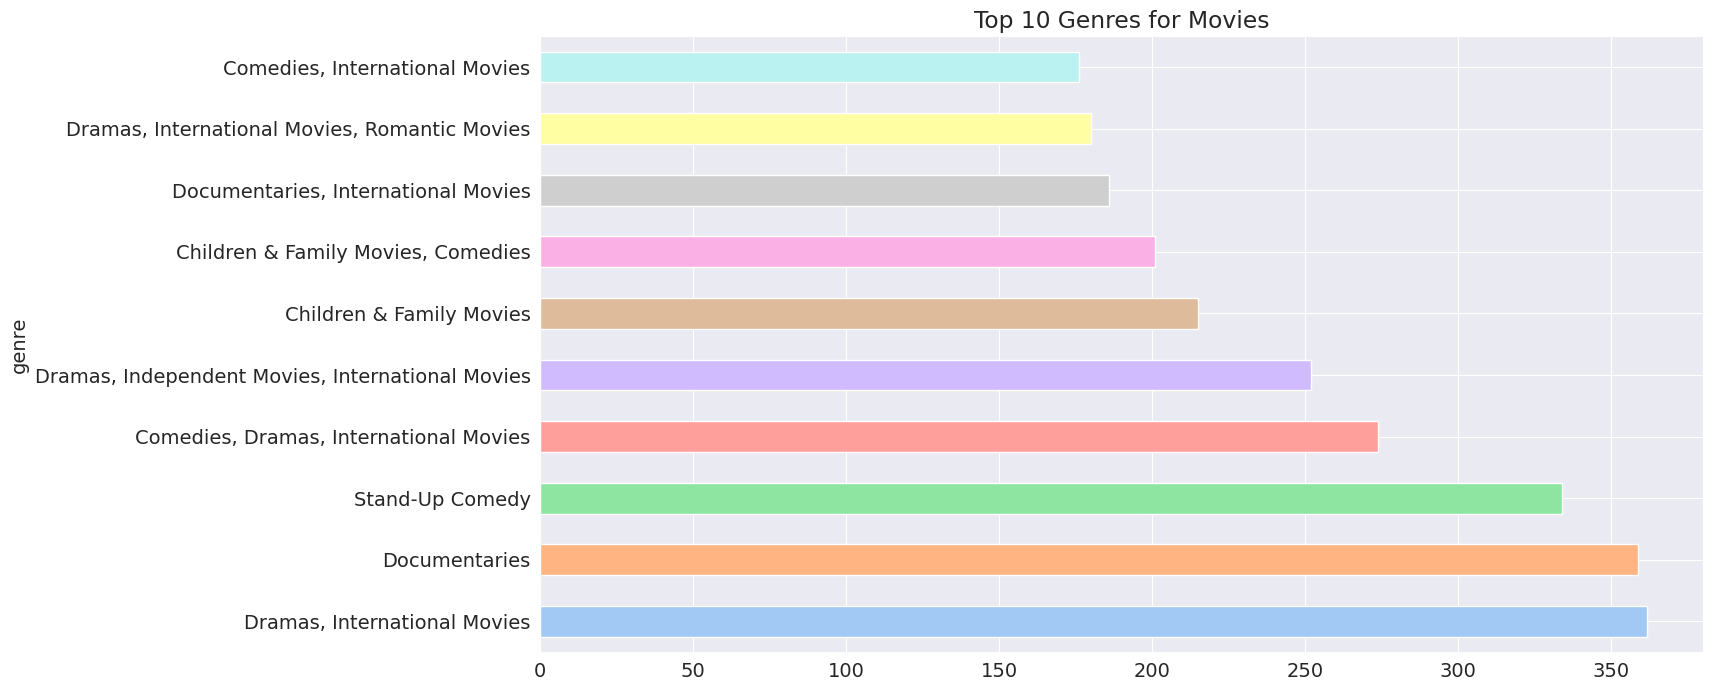

In [23]:
# Count of movie genres
plt.figure(figsize = (15,8))
plt.title('Top 10 Genres for Movies')
colors = sns.color_palette('pastel')
netflix_df[netflix_df["type"]=="Movie"]["genre"].value_counts().head(10).plot(kind='barh', color=colors)
plt.show()

The horizontal bar chart reveals that 'Dramas, International Movies' is the most common movie genre combination (350 titles), followed by 'Documentaries' (350), 'Stand-Up Comedy' (330), 'Comedies, Dramas, International Movies' (250), and 'Dramas, Independent Movies, International Movies' (230). International dramas feature prominently in multiple top combinations, confirming Netflix's heavy investment in non-English language films.

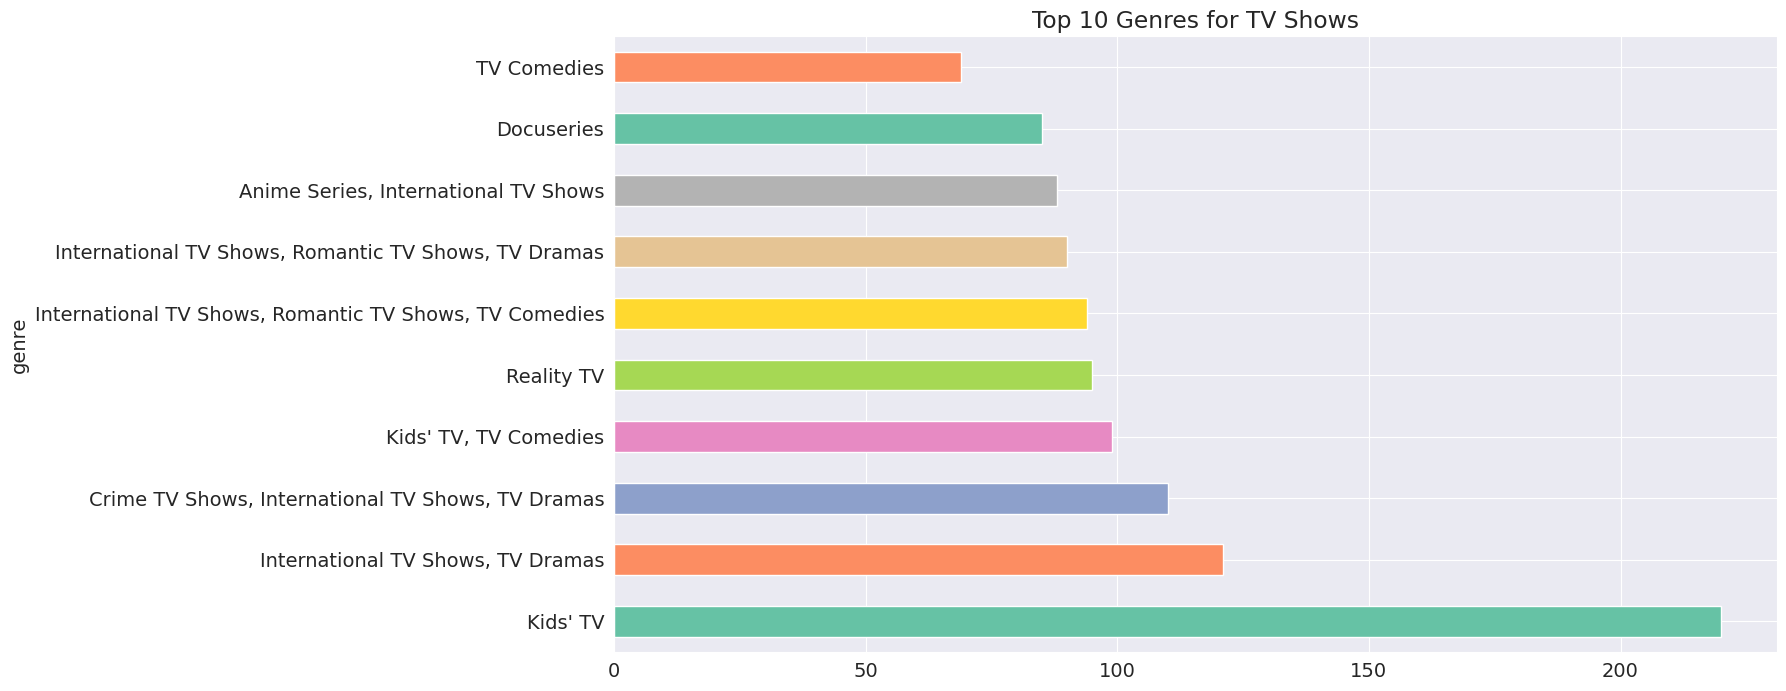

In [24]:
# Count of TV Show genres
plt.figure(figsize = (15,8))
plt.title('Top 10 Genres for TV Shows')
colors = sns.color_palette("Set2")
netflix_df[netflix_df["type"]=="TV Show"]["genre"].value_counts()[:10].plot(kind='barh', color=colors)
plt.show()

For TV Shows, 'Kids' TV' dominates with around 220 titles, followed by 'International TV Shows, TV Dramas' (150), 'Crime TV Shows, International TV Shows, TV Dramas' (115), and 'Kids' TV, TV Comedies' (110). The prominence of Kids' TV and Crime Dramas indicates Netflix strategically serves both family audiences and binge-worthy drama fans.

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2608/3108302804.py:2: SyntaxWarning: invalid escape sequence '\d'
  tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(int)
/tmp/ipykernel_2608/3108302804.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(int)


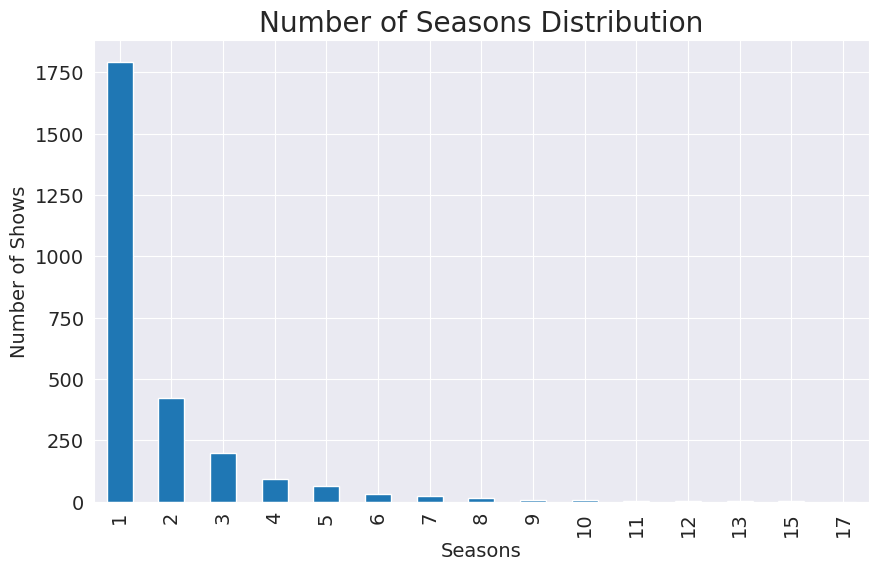

In [25]:
tv_shows = netflix_df[netflix_df['type'] == 'TV Show']
tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(int)

tv_shows['seasons'].value_counts().sort_index().plot(kind='bar', figsize=(10,6))
plt.style.use("fivethirtyeight")
plt.title("Number of Seasons Distribution")
plt.xlabel("Seasons")
plt.ylabel("Number of Shows")
plt.show()

The bar chart shows that the overwhelming majority of TV shows on Netflix (~1,800) have only 1 season. The count drops sharply to ~400 for 2-season shows, ~200 for 3 seasons, and continues declining. Very few shows exceed 5 seasons, with the maximum reaching 17 seasons.
Statistical summary: Mean seasons = 1.78, Median = 1.0, Standard deviation = 1.58. The median of 1 reveals that more than half of all Netflix TV shows are single-season productions — many of which are limited series, docuseries, or stand-alone miniseries. This reflects Netflix's strategy of commissioning limited-run content, which reduces financial risk while allowing high production quality for each season.


In [26]:
tv_shows['seasons'].describe()

,seasons
count,2676.000000
mean,1.764948
std,1.582752
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,17.000000


In [27]:
movies = netflix_df[netflix_df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.extract(r'(\d+)')
movies = movies.dropna(subset=['duration_min'])

movies['duration_min'] = movies['duration_min'].astype(int)
print("Mean:", movies['duration_min'].mean())
print("Median:", movies['duration_min'].median())


Mean: 99.57718668407311
Median: 98.0


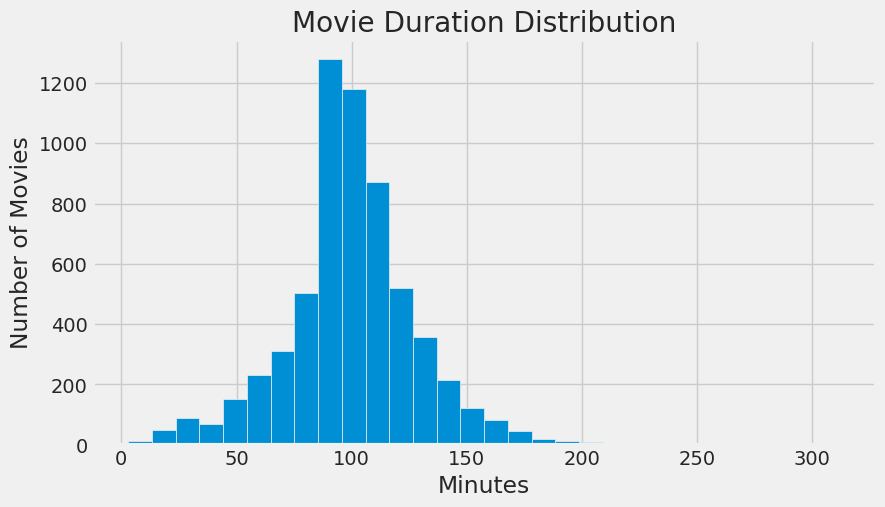

In [28]:
import matplotlib.pyplot as plt

movies['duration_min'].hist(bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Minutes")
plt.ylabel("Number of Movies")

plt.show()

The histogram confirms a roughly normal (slightly right-skewed) distribution centered around 90–100 minutes. The distribution peaks at ~1,200 movies in the 90–100 minute bin. Very few movies are shorter than 60 minutes or longer than 150 minutes.
Statistical summary: Mean duration = 99.57 minutes, Median = 98.0 minutes. The close alignment of mean and median indicates minimal skewness for the core distribution, with outliers only mildly inflating the average.



<Axes: xlabel='duration_min'>

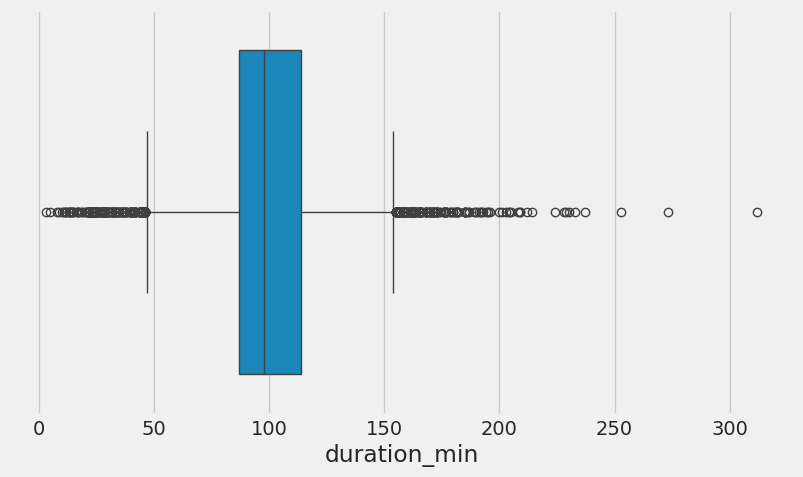

In [29]:
import seaborn as sns

sns.boxplot(x=movies['duration_min'])

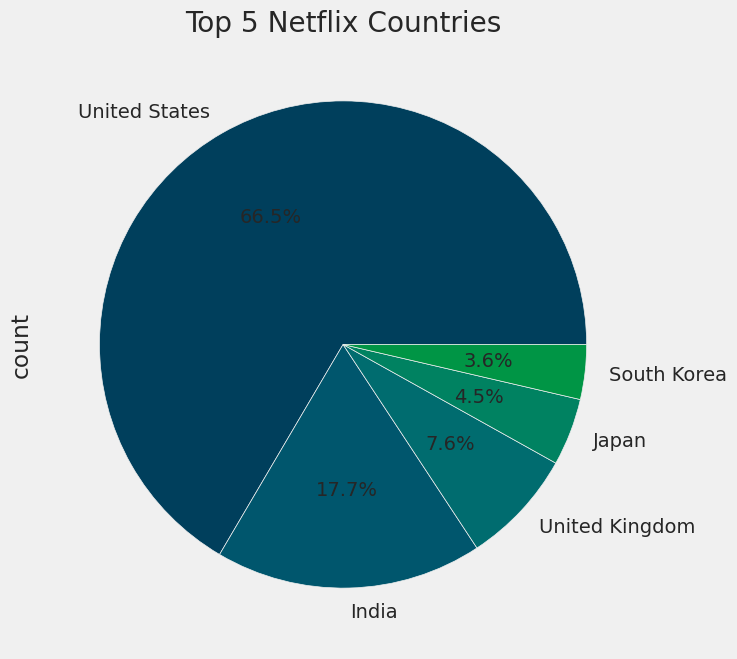

In [30]:
plt.title('Top 5 Netflix Countries')
netflix_df["country"].value_counts().nlargest(n=5).plot.pie(autopct='%1.1f%%',figsize=(7,10), colors=["#003f5c","#00566d","#006c6f","#008261","#009545"])
plt.show()

The pie chart shows the geographic origin of all Netflix content. The United States overwhelmingly dominates at 69.14%, confirming that Hollywood content forms the backbone of Netflix's catalog. India ranks second at 13.7%, reflecting Netflix's strong investment in Bollywood and regional Indian content. The United Kingdom contributes 7.0%, Japan 4.5%, and South Korea 3.6%.

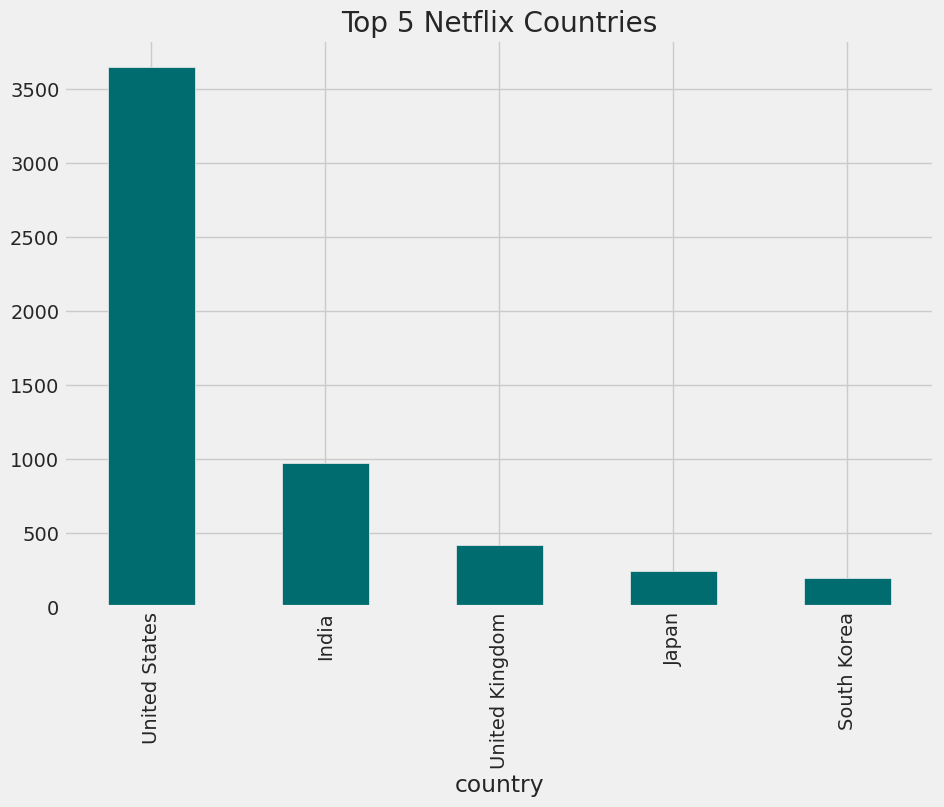

In [45]:
plt.title('Top 5 Netflix Countries')
netflix_df["country"].value_counts().nlargest(n=5).plot.bar(figsize=(10,7), color="#006c6f", )
plt.show()

The bar chart reinforces these proportions with absolute counts: the US has approximately 3,600+ titles, India around 1,000, the UK around 400, Japan around 200, and South Korea around 150.

/tmp/ipykernel_2608/1110254810.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:purple'` for the same effect.

  sns.countplot(x='country', data=netflix_df, hue='type', order=netflix_df.country.value_counts().iloc[:5].index, color="purple")


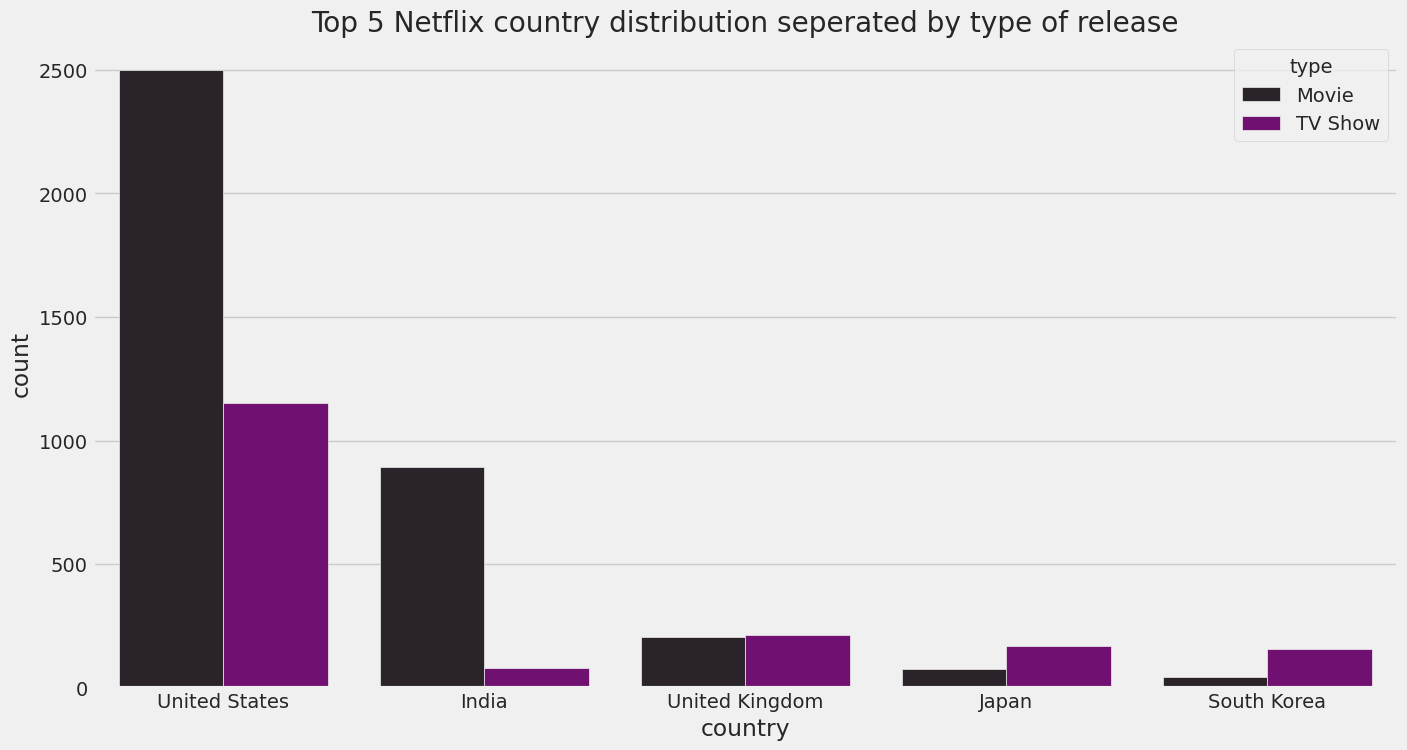

In [32]:
plt.figure(figsize = (15,8))
plt.title('Top 5 Netflix country distribution seperated by type of release')
sns.countplot(x='country', data=netflix_df, hue='type', order=netflix_df.country.value_counts().iloc[:5].index, color="purple")
plt.show()

This grouped bar chart breaks down the top 5 content-producing countries by content type (Movie in black, TV Show in purple). The United States leads in both movies (approximately 2,500) and TV shows (approximately 1,100). India's content is almost exclusively movies, with a very small TV show output. The United Kingdom, Japan, and South Korea show more balanced ratios, with South Korea and Japan having relatively higher TV show proportions compared to India.

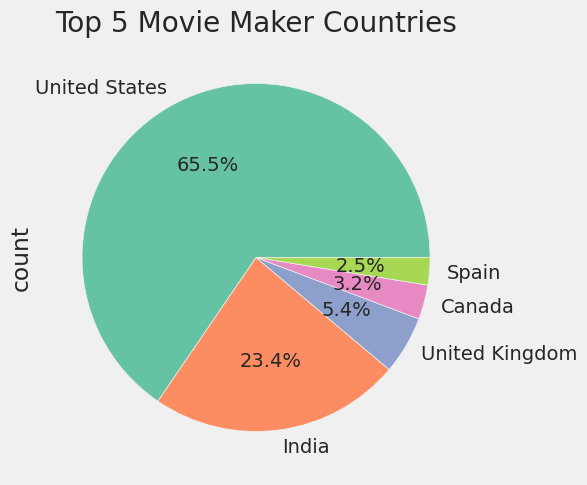

In [33]:
plt.title('Top 5 Movie Maker Countries')
colors = sns.color_palette("Set2")
netflix_df[netflix_df["type"]=="Movie"]["country"].value_counts().nlargest(n=5).plot.pie(autopct='%1.1f%%',figsize=(5,10), colors=colors)
plt.show()

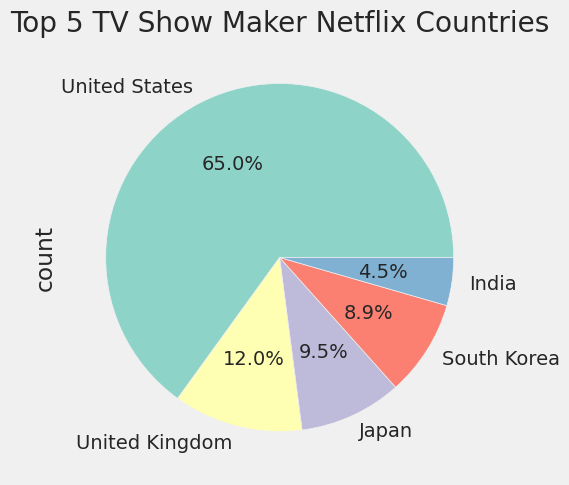

In [34]:
plt.title('Top 5 TV Show Maker Netflix Countries')
colors = sns.color_palette("Set3")
netflix_df[netflix_df["type"]=="TV Show"]["country"].value_counts().nlargest(n=5).plot.pie(autopct='%1.1f%%',figsize=(5,10), colors=colors)
plt.show()

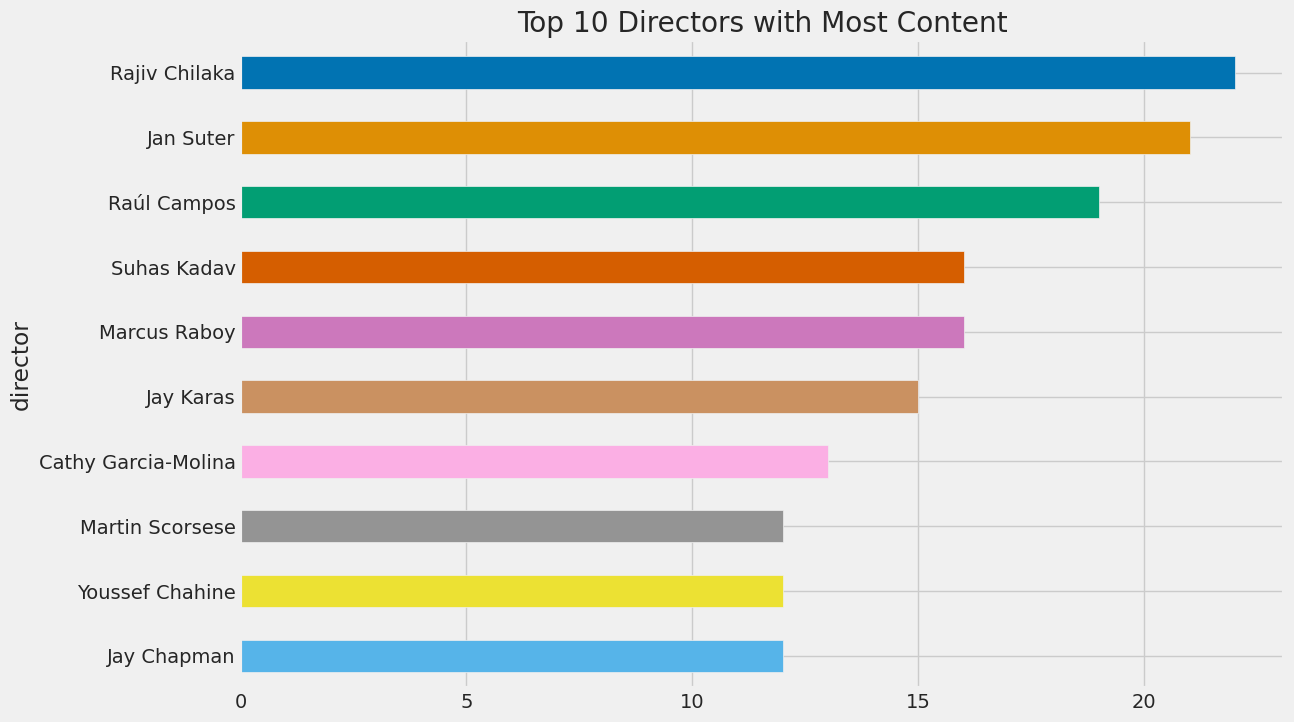

In [46]:
plt.figure(figsize=(12,8))
colors=sns.color_palette("colorblind")
netflix_df['director']\
.dropna()\
.str.split(', ')\
.explode()\
.value_counts()\
.head(10)\
.plot(kind='barh', color=colors)

plt.title("Top 10 Directors with Most Content")
plt.gca().invert_yaxis()

plt.show()

Rajiv Chilaka leads all directors with approximately 22 titles, followed by Jan Suter (21), Raúl Campos (18), Suhas Kadav (16), and Marcus Raboy (16). Martin Scorsese notably appears at #8 with around 12 titles — reflecting Netflix's deals with acclaimed filmmakers to offer their back catalogues.

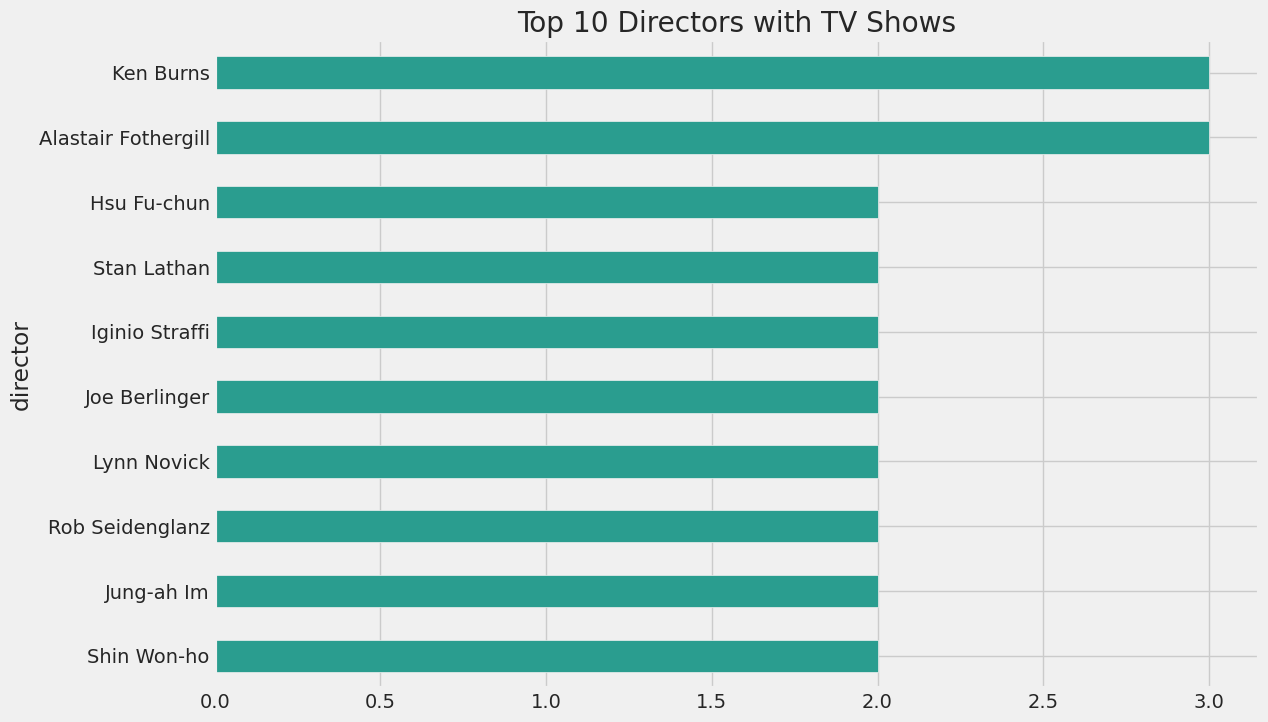

In [47]:
plt.figure(figsize=(12,8))
sns.color_palette("hls", 8)
netflix_df[netflix_df['type'] == 'TV Show']['director']\
.dropna()\
.str.split(', ')\
.explode()\
.value_counts()\
.head(10)\
.plot(kind='barh', color="#2a9d8f")

plt.title("Top 10 Directors with TV Shows")
plt.gca().invert_yaxis()

plt.show()

Ken Burns and Alastair Fothergill lead TV Show directors, each with about 3 titles. The remainder all have around 2 titles, indicating that TV show direction is far more evenly distributed and no single director dominates the category.
The contrast between movie and TV show director concentration reveals that movie production on Netflix relies more heavily on prolific individual directors, while TV shows are spread across a broader creative talent pool.


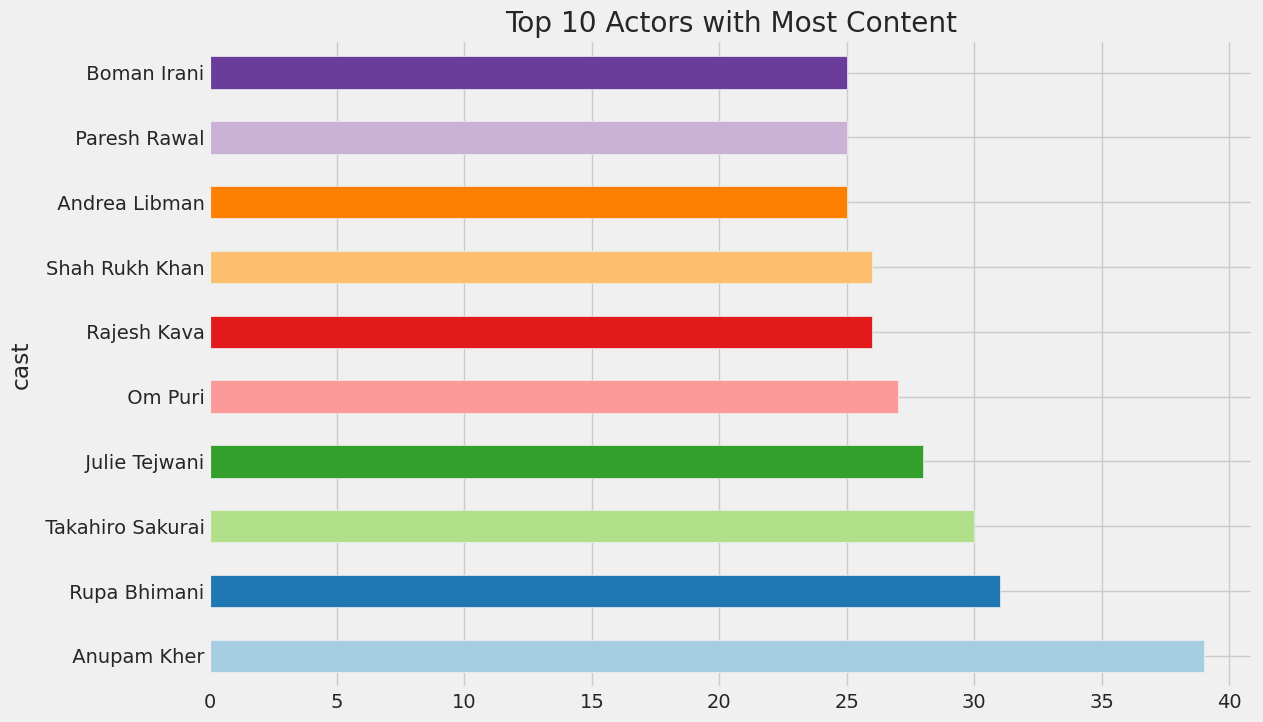

<Figure size 1700x800 with 0 Axes>

In [48]:
plt.figure(figsize=(12,8))
colors=sns.color_palette("Paired")
netflix_df['cast']\
.dropna()\
.str.split(',')\
.explode()\
.value_counts()\
.head(10)\
.plot(kind='barh', color=colors)

plt.title("Top 10 Actors with Most Content")
plt.figure(figsize=(17,8))
plt.show()

Anupam Kher leads all actors with approximately 39 titles, followed by Rupa Bhimani (31), Takahiro Sakurai (30), Julie Tejwani (29), and Om Puri (26). The dominance of Indian actors (Anupam Kher, Om Puri, Shah Rukh Khan, Paresh Rawal, Boman Irani) reflects the large volume of Bollywood content on Netflix. Takahiro Sakurai and Rupa Bhimani are Japanese and likely voice actors for anime content.
This chart reinforces that Netflix's content is globally diverse, with Bollywood and anime voice acting communities well-represented in the top talent rankings.



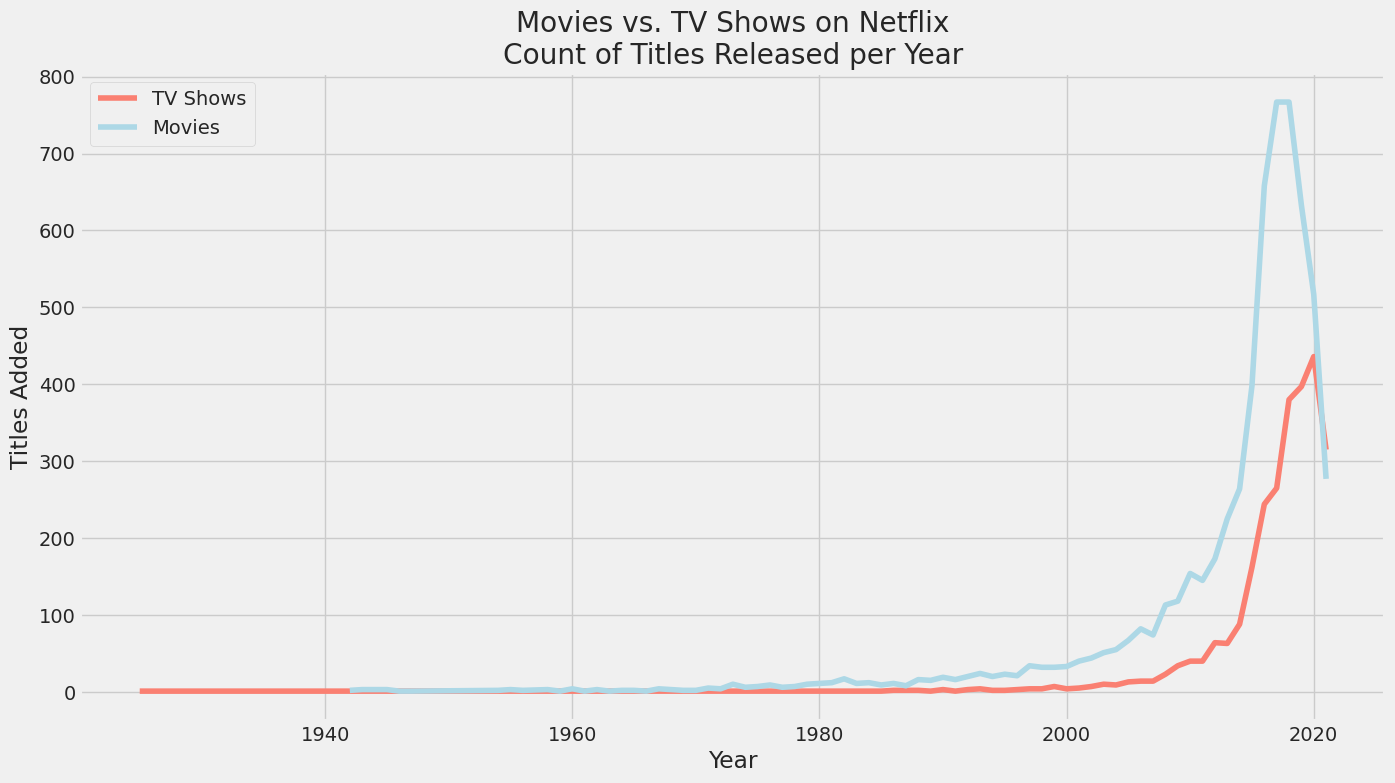

In [49]:
plt.figure(figsize=(15,8))

plt.plot(netflix_df[netflix_df['type']=='TV Show'].groupby('release_year')['type'].count(), color='salmon', linewidth=4)
plt.plot(netflix_df[netflix_df['type']=='Movie'].groupby('release_year')['type'].count(), color='lightblue',linewidth=4)
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.title("Movies vs. TV Shows on Netflix\nCount of Titles Released per Year")
plt.legend(['TV Shows','Movies'])

plt.show()

This dual-line chart tracks the annual count of Movies (light blue) and TV Shows (salmon/red) added to Netflix from the 1940s to 2021. Both lines remain essentially flat until around 2010, at which point they begin rising sharply.

•	Movies saw an explosive spike peaking around 2019–2020, reaching nearly 750 titles added in a single year before declining sharply.

•	The post-2019 dip in both lines is likely attributable to production halts caused by the global pandemic.

•	The gap between Movies and TV Shows remains consistent throughout — movies always lead in volume — though the lines converge slightly in recent years, suggesting Netflix may be increasing its TV Show investment.

This chart powerfully illustrates Netflix's growth trajectory and its transition from a DVD rental service to a dominant global streaming platform.


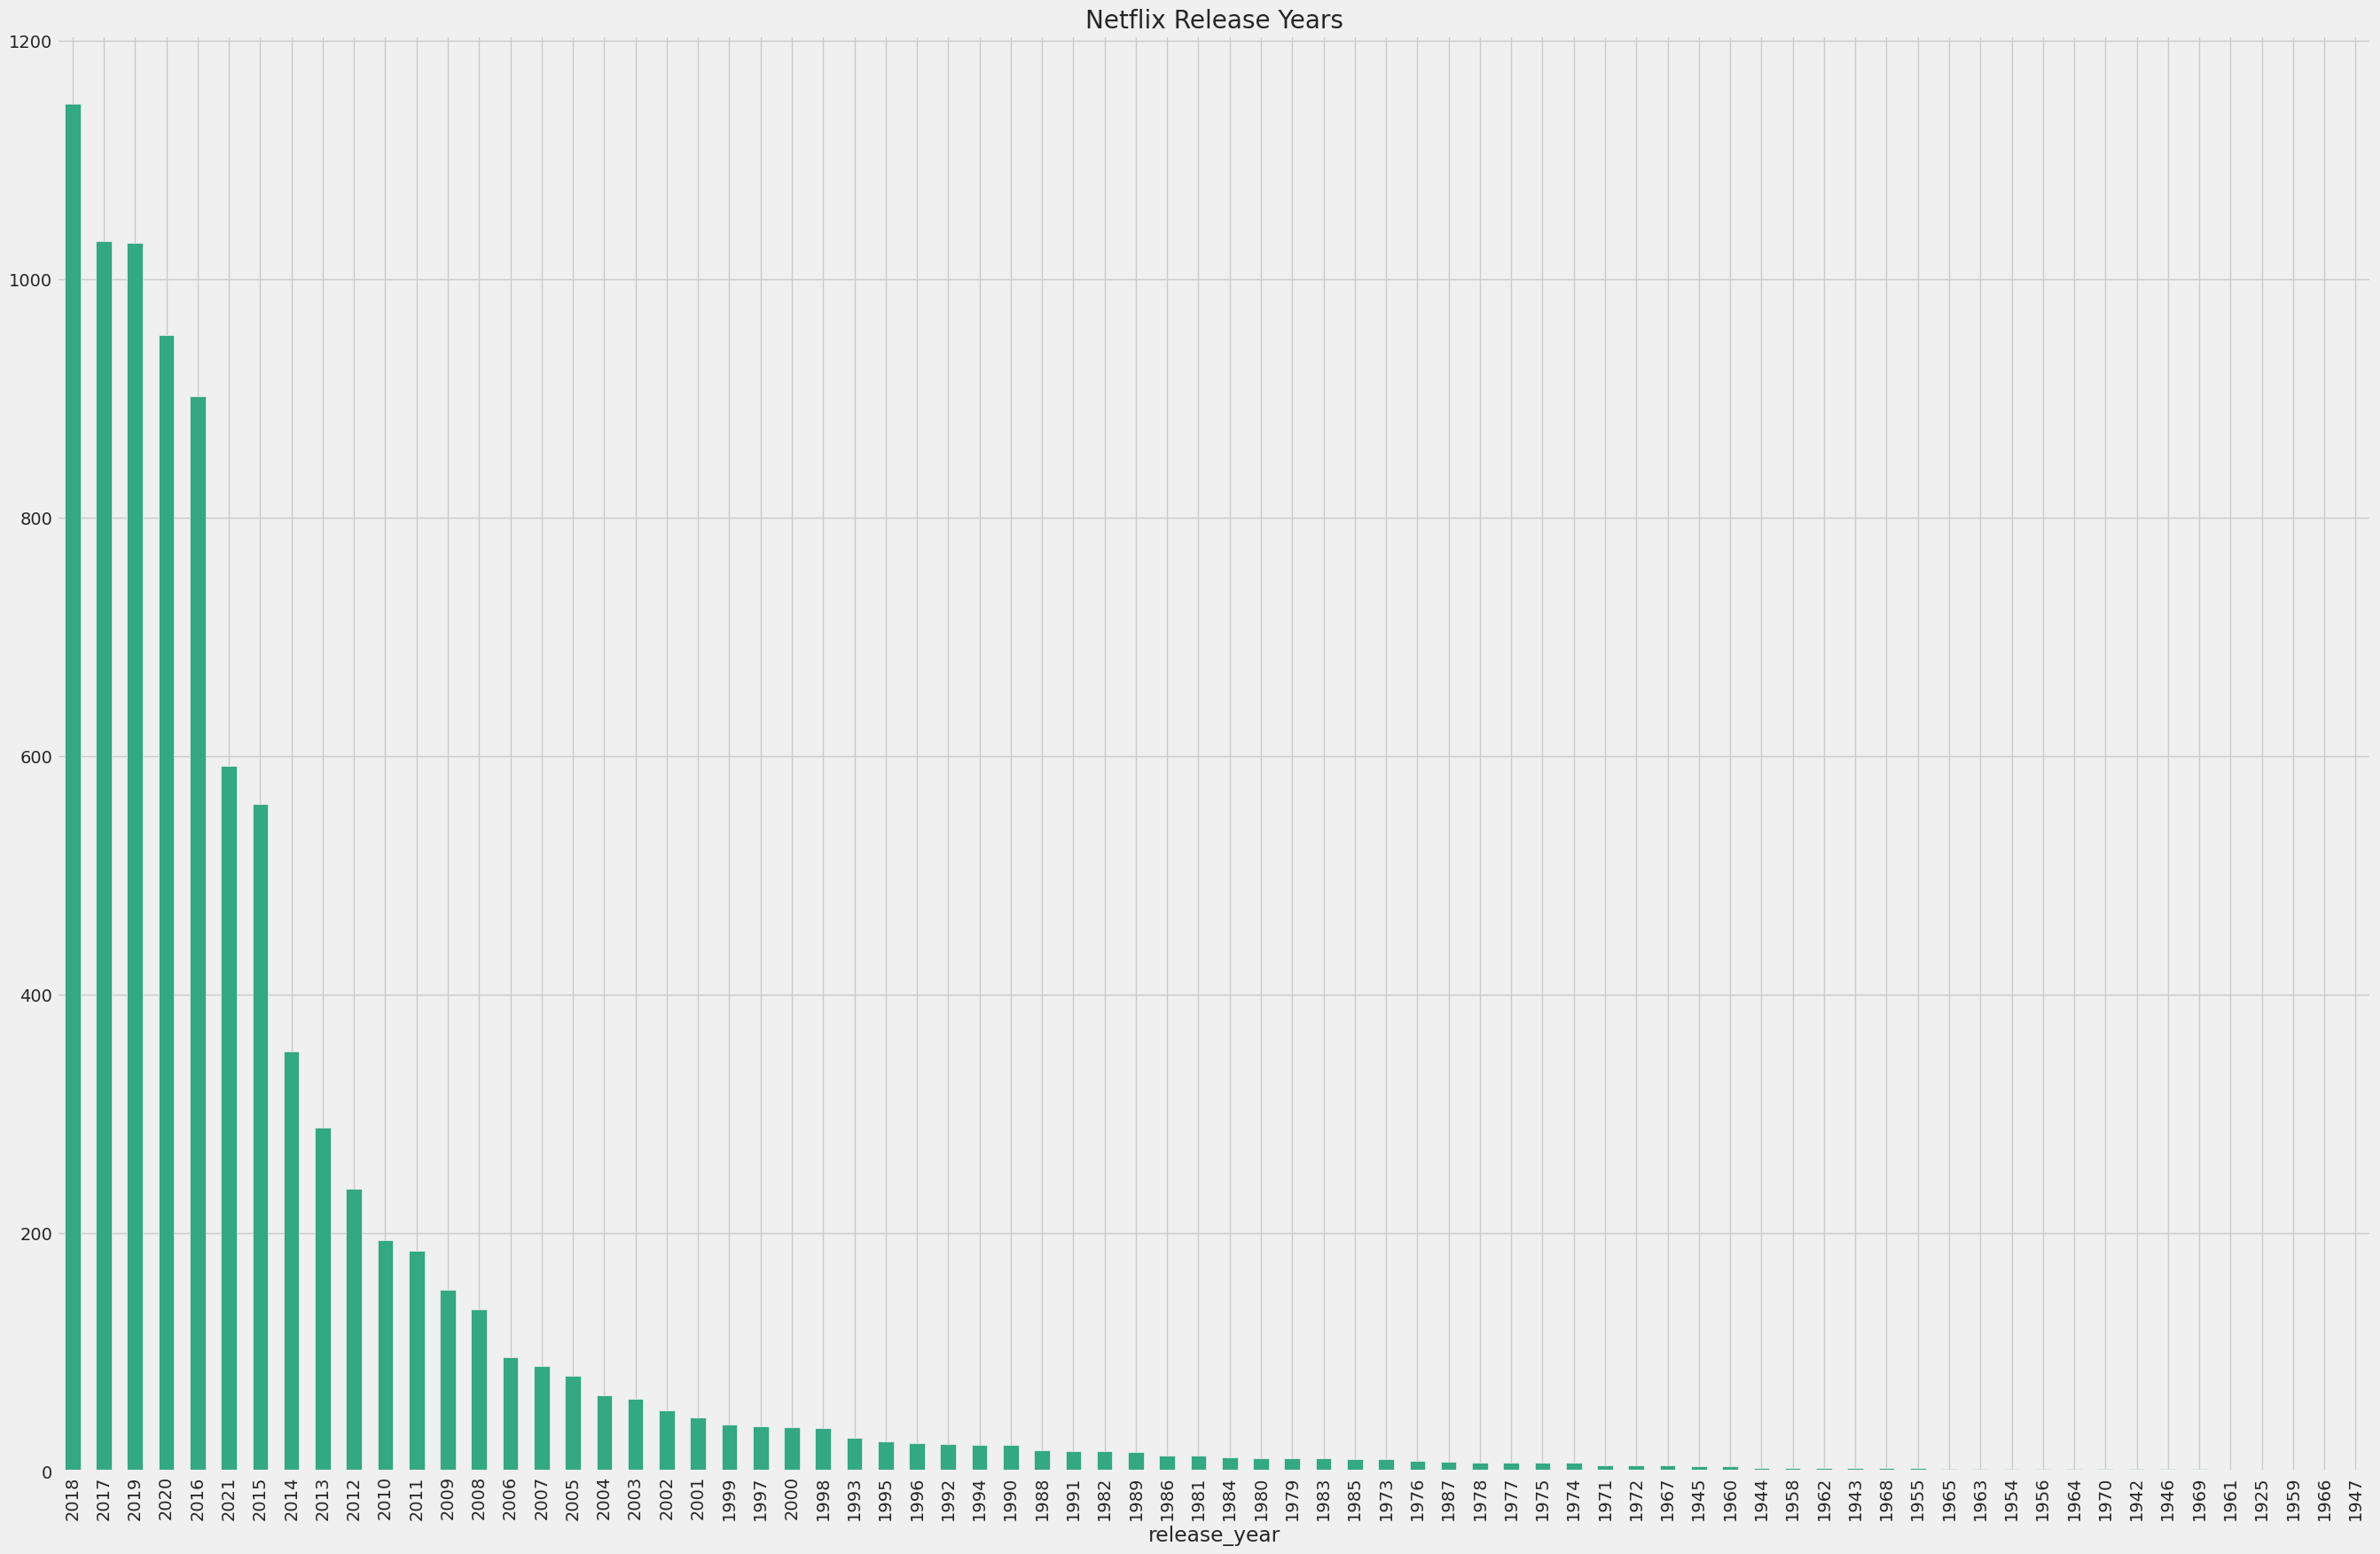

In [50]:
plt.title('Netflix Release Years')
netflix_df["release_year"].value_counts().plot.bar(figsize=(30,20), color="#32a883")
plt.show()

This horizontal bar chart visualizes how many titles were released each year, sorted from most recent (2021) at the top to the earliest available titles (1940s and earlier) at the bottom. The distribution is sharply right-skewed — meaning the vast majority of content was released in recent years.

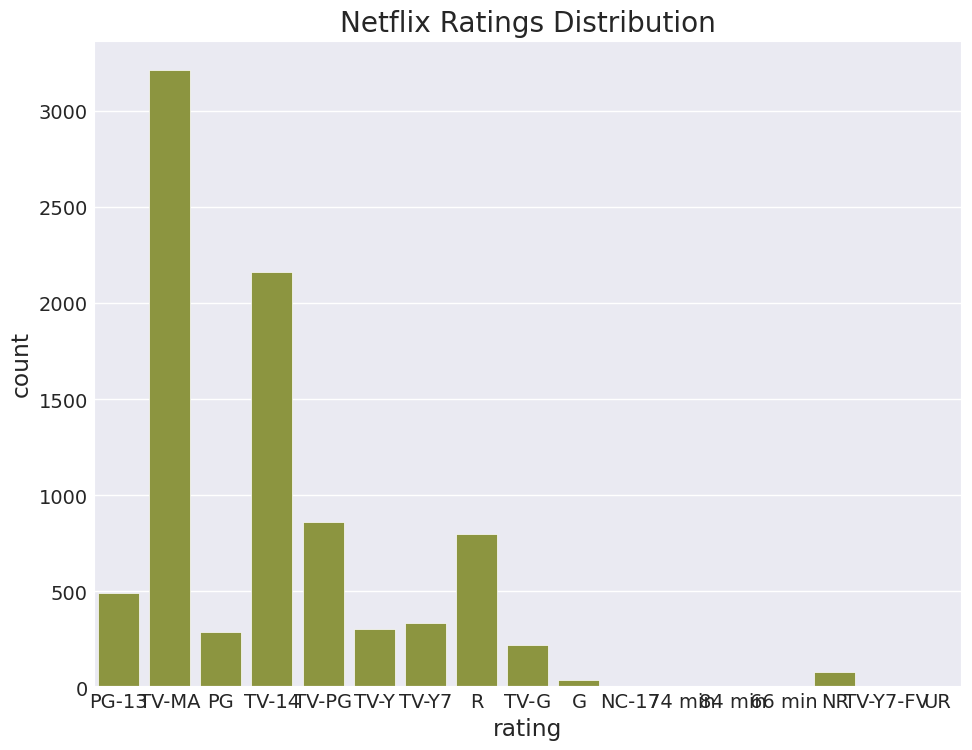

In [72]:
colors=sns.color_palette("husl", 8)
plt.figure(figsize = (10,8))
plt.title('Netflix Ratings Distribution')
sns.countplot(x='rating', data = netflix_df, color=colors[2])
plt.show()

The bar chart of all ratings shows TV-MA as the most common rating with over 3,000 titles, followed by TV-14 (~2,200), TV-PG (~900), R (~800), and PG-13 (~500). G, TV-G, NC-17 and other ratings are marginal. This indicates Netflix's catalog skews heavily toward mature and teen audiences, with adult content (TV-MA) being the single largest category.

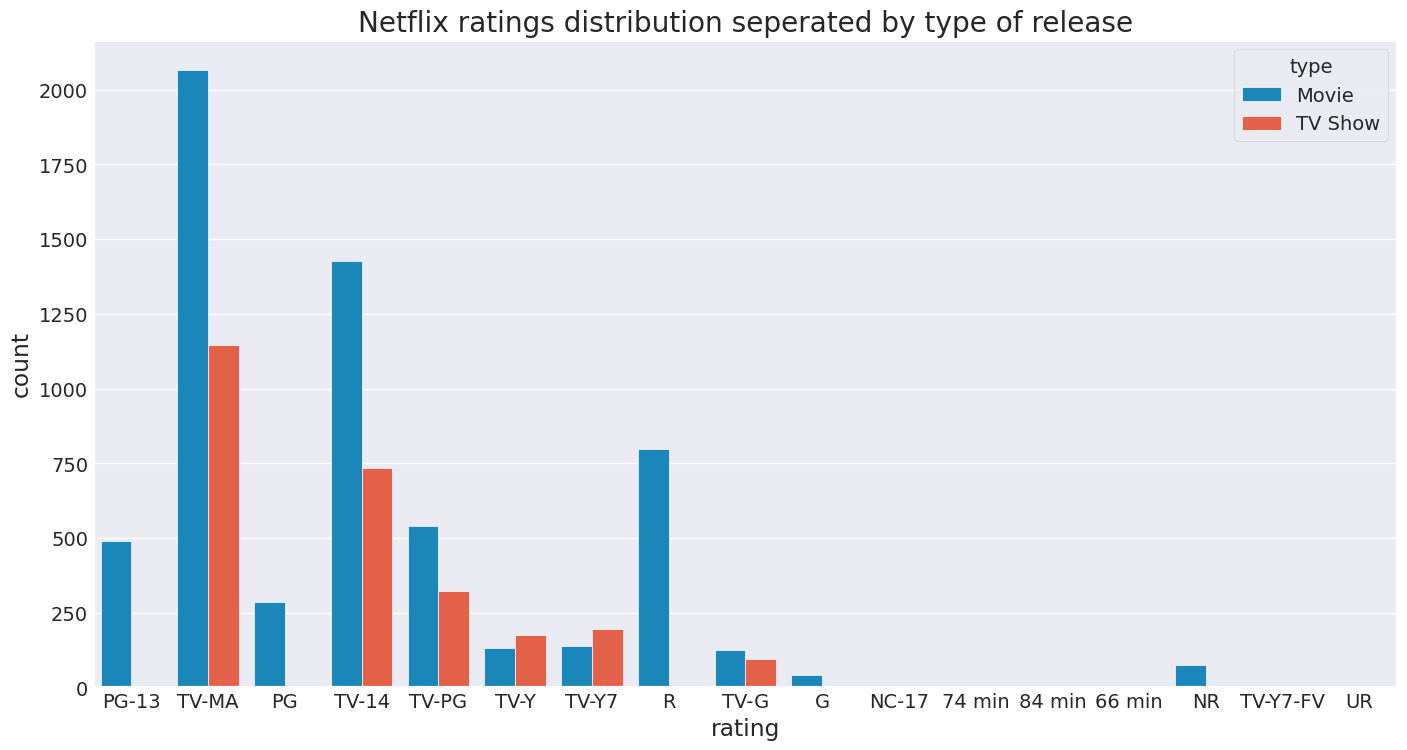

In [71]:
plt.figure(figsize = (15,8))
plt.title('Netflix ratings distribution seperated by type of release')
# Plotting The CountPLOT
sns.countplot(x='rating', data=netflix_df, hue="type")
plt.show()

The grouped bar chart reveals important differences:
•	TV-MA: Movies (2,050) and TV Shows (1,100) — mature content dominates both formats.
•	TV-14: Movies (1,450) and TV Shows (750) — the second largest category for both.
•	R-rated content is almost exclusively movies, as expected.
•	TV-G and TV-Y ratings appear only in TV Shows, confirming children's content is delivered via series rather than films on Netflix.
This rating distribution suggests Netflix's primary audience is adults aged 17+, though children's content exists as a secondary segment primarily in TV format.


**Overall EDA Summary & Key Insights**
The Netflix content dataset, when analyzed holistically, paints a clear picture of a platform that has evolved from a US-centric movie library into a globally diverse, multi-format entertainment powerhouse. Below are the overarching conclusions:

**1. Content Volume & Format**

Netflix's catalog is predominantly movie-driven (69.62%), with TV Shows making up about 30%. However, the TV Show segment is growing rapidly relative to movies, and its impact on viewership likely exceeds its volume share due to the binge-watching model that keeps subscribers engaged for longer periods.

**2. Recency Bias**

The dataset is overwhelmingly skewed toward recent years, with 2016–2019 representing the peak of content acquisition. This reflects Netflix's aggressive expansion strategy during that period. The post-2019 drop signals both the pandemic effect and a potential shift from volume-based growth to quality-focused curation.

**3. US Dominance with Emerging International Diversity**

The United States provides roughly 65–70% of all content for both movies and TV shows. India is a strong second, particularly in movies, while South Korea and Japan punch above their weight in TV shows — driven by K-dramas and anime. This signals that international content is no longer supplementary; it is a core growth driver for Netflix globally.

**4. Mature Audience Focus**

The ratings distribution clearly shows that TV-MA and TV-14 dominate, positioning Netflix as a platform primarily for adults and teenagers. Children's content exists but is primarily delivered through TV shows (TV-G, TV-Y ratings), and represents a much smaller portion of the catalog.

**5. Genre Strategy: Depth Over Breadth**

Netflix's genre tagging system reveals a preference for multi-genre blending (e.g., 'Comedies, Dramas, International Movies'). Dramas and International content appear in most top genre combinations, confirming that Netflix sees global drama as its most bankable genre. Documentaries and Stand-Up Comedy are strong standalone categories for movies, while Kids' TV and Crime Dramas anchor the TV show catalog.

**6. Creator Concentration in Movies vs. TV Shows**

Movie content shows higher director concentration — a handful of prolific directors like Rajiv Chilaka and Jan Suter account for a disproportionate share of titles. TV show direction is far more distributed, with no single creator dominating the space. Similarly, the top actors are disproportionately Indian (Bollywood) and Japanese (anime voice actors), reflecting the geographic content mix.

**7. Duration Consistency**

Movie durations cluster tightly around 90–100 minutes, well within the industry standard for feature films. TV shows are predominantly single-season productions (median = 1 season), indicating Netflix's preference for limited series that minimize long-term production commitments while maximizing creative impact.

**8. Strategic Implications**

Netflix's data reveals a platform at an inflection point: historically driven by US movies, it is rapidly diversifying into international TV, genre niche content, and limited-run series. The challenge ahead is balancing this volume-driven catalog with quality and subscriber retention, particularly as competition from Disney+, HBO Max, and Amazon Prime intensifies. The data suggests Netflix's best competitive differentiators lie in its international content depth, its mature audience programming, and its growing anime and K-drama library.


**Chart-by-chart breakdowns:**

-Content type split (Movies 69.6% vs TV Shows 30.4%)

-Release year distribution (peak 2017–2019, COVID dip after)

-Movies vs TV Shows growth timeline

-Top 5 countries (US dominates at ~65–70%, India strong second)
Country breakdown by content type (South Korea/Japan lead in TV)

-Ratings (TV-MA is #1, adult audience skew)

-Top 10 genres for Movies and TV Shows separately

-Most popular individual genre tags (TV Horror, Anime, Cult Movies lead)

-Top directors and actors (Bollywood & anime voice actors dominate)

-Movie duration stats (mean ~99 min, normal distribution)

-TV show seasons (median = 1 season, single-season dominated)